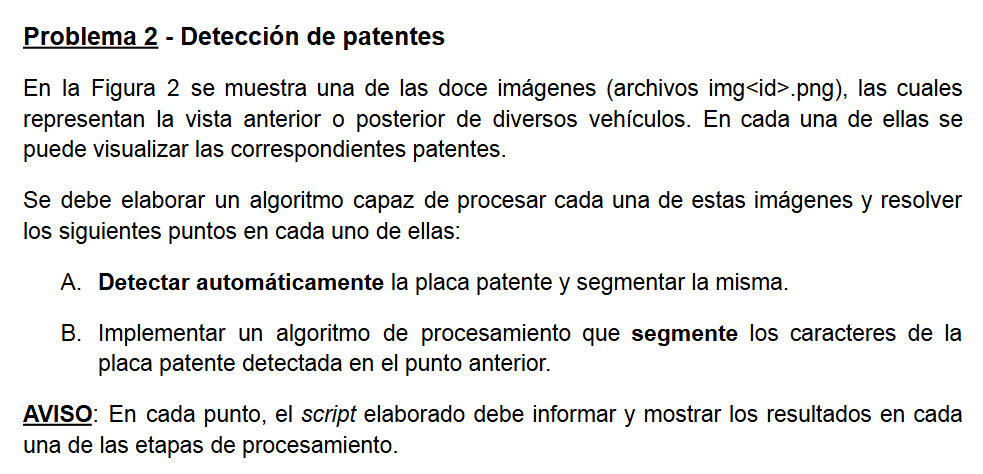

In [8]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

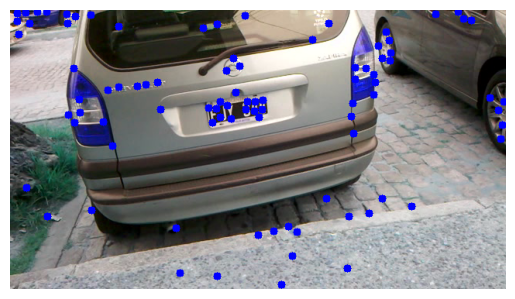

In [9]:
img = cv2.imread('img/img05.png')

img_shi_tomasi = img.copy()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gray = np.float32(gray)

corners = cv2.goodFeaturesToTrack(
    image=gray, 
    maxCorners=90,        # Queremos encontrar solo las 10 esquinas más fuertes (4 son las de la patente)
    qualityLevel=0.01,    # Umbral de calidad: 1% del valor máximo de la respuesta de esquina
    minDistance=10       # Distancia mínima en píxeles entre esquinas detectadas (para eliminar aglomeraciones)
)

# El resultado 'corners' es una matriz de coordenadas flotantes

# 3. Dibujar las esquinas detectadas
# Aseguramos que 'corners' no sea None y que tenga elementos
if corners is not None:
    # Convertir las coordenadas a enteros y dibujar un círculo
    corners = corners.astype(int)
    for i in corners:
        x, y = i.ravel()
        # Dibujar un círculo rojo en cada esquina detectada
        cv2.circle(img_shi_tomasi, (x, y), 5, (0, 0, 255), -1)

# 7. Mostrar la imagen con las esquinas detectadas
plt.imshow(img_shi_tomasi)
plt.axis('off')
plt.show()

Resultado: Patente detectada por forma de contorno.


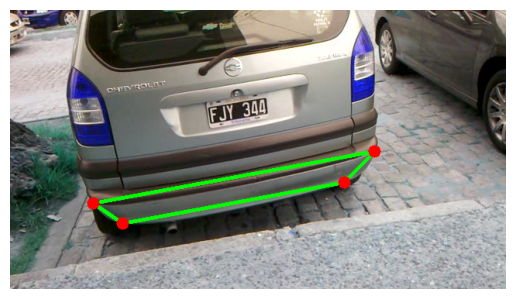

In [ ]:
def detectar_patente(ruta_imagen):
    img = cv2.imread(ruta_imagen)
    if img is None: return

    # 1. Preprocesamiento: Escala de grises y Canny para encontrar bordes fuertes
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Aplicar un filtro (ej. Bilateral) para preservar bordes y eliminar ruido
    filtered = cv2.bilateralFilter(gray, 11, 17, 17)
    edged = cv2.Canny(filtered, 30, 200) # Canny Edge Detection

    # 2. Encontrar Contornos
    # cv2.RETR_TREE: Retorna una jerarquía completa de contornos
    # cv2.CHAIN_APPROX_SIMPLE: Comprime segmentos rectos
    contours, hierarchy = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    # Ordenar los contornos por área descendente
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    
    patente_contorno = None
    
    # 3. Iterar y Encontrar la Matrícula por Forma (4 vértices y Aspect Ratio)
    for c in contours:
        # Aproximar el contorno a un polígono
        perimeter = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * perimeter, True) # Buscamos una forma cerrada
        
        # Si la forma tiene 4 vértices (un cuadrilátero)
        if len(approx) == 4:
            x, y, w, h = cv2.boundingRect(approx)
            aspect_ratio = w / float(h)
            
            # Filtramos por Aspect Ratio típico de una patente (ej. 3.5 a 5.0)
            if 3.5 <= aspect_ratio <= 5.5:
                # Una vez que encontramos un cuadrilátero que se parece a una patente
                patente_contorno = approx
                break # Salimos del bucle
                
    # 4. Dibujar el resultado
    if patente_contorno is not None:
        img_final = img.copy()
        cv2.drawContours(img_final, [patente_contorno], -1, (0, 255, 0), 3) # Verde
        print("Resultado: Patente detectada por forma de contorno.")
        
        # Los vértices de la patente son los puntos en 'patente_contorno'
        for point in patente_contorno:
             x, y = point[0]
             cv2.circle(img_final, (x, y), 8, (255, 0, 0), -1) # Azul
    else:
        img_final = img
        print("Fallo: No se encontró un contorno rectangular con el ratio esperado.")

    plt.imshow(img_final)
    plt.axis('off')
    plt.show()  

detectar_patente('img/img05.png')

Fallo: No se encontró ningún contorno que cumpliera los filtros geométricos.


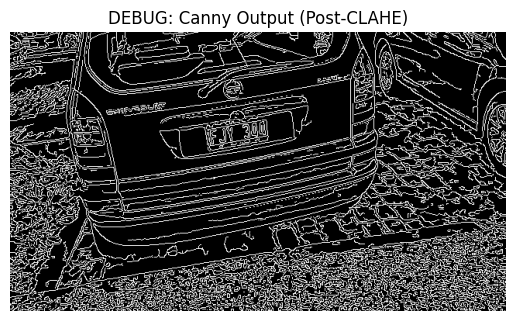

In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detectar_patente_final_centroide_revisado(ruta_imagen):
    """
    Combina CLAHE/Canny con la heurística de distancia al centroide de la placa.
    """
    img = cv2.imread(ruta_imagen)
    if img is None:
        print(f"Error: No se pudo cargar la imagen en la ruta: {ruta_imagen}")
        return

    H_img, W_img, _ = img.shape 
    
    # Centroide Objetivo (Target): Centro horizontal y 65% a 70% de la altura vertical
    TARGET_CENTER_X = W_img // 2
    TARGET_CENTER_Y = int(H_img * 0.65) # Ubicado justo encima del parachoques
    
    # 1. Preprocesamiento: CLAHE y Canny (MEJOR MÁSCARA ENCONTRADA)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl1 = clahe.apply(gray)
    filtered = cv2.bilateralFilter(cl1, 11, 17, 17)
    edged = cv2.Canny(filtered, 20, 100)
    
    # 2. Encontrar Contornos
    contours, _ = cv2.findContours(edged.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    
    mejor_patente = None
    min_distancia = float('inf')
    
    # 3. Parámetros y Filtros
    ASPECT_RATIO_MIN = 4.3 
    ASPECT_RATIO_MAX = 5.5 
    AREA_MIN_UMBRAL = 500
    AREA_MAX_UMBRAL = 15000 # Permitir contornos grandes para que la distancia los penalice
    
    for c in contours:
        area = cv2.contourArea(c)

        # 3.1. Filtro por Área
        if area < AREA_MIN_UMBRAL or area > AREA_MAX_UMBRAL:
            continue
            
        x, y, w, h = cv2.boundingRect(c)
        
        # --- FILTRO 1: RESTRICCIÓN DE POSICIÓN Y (SÓLO MITAD INFERIOR) ---
        if y < H_img * 0.5: 
            continue
        
        # 3.2. Filtro por Forma (Restricción de vértices RELAJADA)
        perimeter = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * perimeter, True) 
        
        # Permitir un cuadrilátero aproximado (más robusto)
        if not (4 <= len(approx) <= 8):
            continue
            
        # 3.3. Filtro por Relación de Aspecto
        min_area_rect = cv2.minAreaRect(c)
        (center, (width, height), angle) = min_area_rect

        if width < height:
            width, height = height, width
            
        if height == 0:
            continue
            
        aspect_ratio = width / height
        
        if ASPECT_RATIO_MIN <= aspect_ratio <= ASPECT_RATIO_MAX:
            
            # --- HEURÍSTICA CLAVE: DISTANCIA AL CENTROIDE OBJETIVO ---
            # Calcular el centroide del contorno actual
            M = cv2.moments(c)
            if M["m00"] == 0:
                continue
                
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])
            
            # Calcular la distancia euclidiana 
            distancia = np.sqrt((cX - TARGET_CENTER_X)**2 + (cY - TARGET_CENTER_Y)**2)
            
            if distancia < min_distancia:
                min_distancia = distancia
                mejor_patente = min_area_rect
            # --------------------------------------------------------
            
    # 4. Dibujar el resultado
    img_final = img.copy()

    if mejor_patente is not None:
        box_points_float = cv2.boxPoints(mejor_patente)
        box_points_int = np.int32(box_points_float)
        
        cv2.drawContours(img_final, [box_points_int], 0, (0, 255, 0), 3) 
        
        # Dibujar el centroide objetivo (rojo) y el centro de la placa detectada (azul)
        cv2.circle(img_final, (TARGET_CENTER_X, TARGET_CENTER_Y), 8, (255, 0, 0), -1) 
        center_x, center_y = [int(val) for val in mejor_patente[0]]
        cv2.circle(img_final, (center_x, center_y), 8, (0, 0, 255), -1) 
        
        print(f"Resultado: Patente detectada mediante heurística de centroide y filtros.")
        
    else:
        print("Fallo: No se encontró ningún contorno que cumpliera los filtros geométricos.")
        
        # DEBUG: Muestra la máscara Canny
        plt.imshow(edged, cmap='gray')
        plt.title("DEBUG: Canny Output (Post-CLAHE)")
        plt.axis('off')
        plt.show()
        return

    plt.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Detección de Patente (Final)")
    plt.show()

detectar_patente_final_centroide_revisado('img/img05.png')

Fallo: No se encontró un contorno con alta Solidez y las propiedades esperadas.


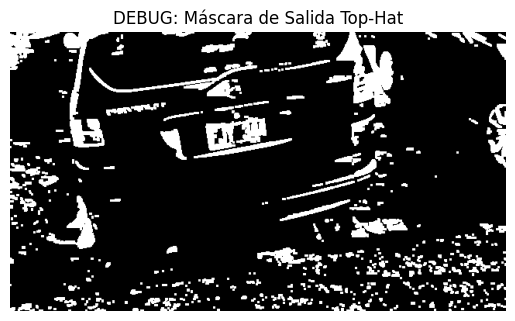

In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detectar_patente_final_solidez(ruta_imagen):
    """
    Detecta la patente usando Top-Hat y el filtro de SOLIDEZ para eliminar contornos irregulares masivos.
    """
    img = cv2.imread(ruta_imagen)
    if img is None:
        print(f"Error: No se pudo cargar la imagen en la ruta: {ruta_imagen}")
        return

    H_img, W_img, _ = img.shape 
    Y_POS_UMBRAL = H_img * 0.5 
    
    # 1. Preprocesamiento: Gradiente Morfológico (Top-Hat) - El mejor preprocesamiento encontrado
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 5)) 
    tophat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)
    _, mask_placa = cv2.threshold(tophat, 50, 255, cv2.THRESH_BINARY)
    kernel_dilate = np.ones((3, 3), np.uint8)
    mask_placa = cv2.dilate(mask_placa, kernel_dilate, iterations=1)

    # 2. Encontrar Contornos
    contours, _ = cv2.findContours(mask_placa.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    
    patente_rectangulo = None
    
    # 3. Parámetros y Filtros
    ASPECT_RATIO_MIN = 4.5 
    ASPECT_RATIO_MAX = 5.0 
    AREA_MIN_UMBRAL = 500
    AREA_MAX_UMBRAL = 5000 
    SOLIDEZ_MIN = 0.85 # La placa debe llenar al menos el 85% de su bounding box
    
    for c in contours:
        area = cv2.contourArea(c)

        # 3.1. Filtro por Área
        if area < AREA_MIN_UMBRAL or area > AREA_MAX_UMBRAL:
            continue
            
        x, y, w, h = cv2.boundingRect(c)
        
        # --- FILTRO CLAVE DE SOLIDEZ ---
        bounding_rect_area = w * h
        if bounding_rect_area == 0:
            continue
            
        solidez = area / bounding_rect_area
        
        # Si la solidez es baja, es un contorno irregular (como el parachoques)
        if solidez < SOLIDEZ_MIN: 
             continue
        # ------------------------------------

        # --- FILTRO 1: RESTRICCIÓN DE POSICIÓN Y ---
        if y < Y_POS_UMBRAL: 
            continue
        
        # 3.2. Filtro por Forma (Restricción de vértices)
        perimeter = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * perimeter, True) 
        
        # Mantenemos el rango de 4 a 6 vértices
        if not (4 <= len(approx) <= 6):
            continue
            
        # 3.3. Filtro por Relación de Aspecto
        min_area_rect = cv2.minAreaRect(c)
        (center, (width, height), angle) = min_area_rect

        if width < height:
            width, height = height, width
            
        if height == 0:
            continue
            
        aspect_ratio = width / height
        
        if ASPECT_RATIO_MIN <= aspect_ratio <= ASPECT_RATIO_MAX:
            patente_rectangulo = min_area_rect
            break # Éxito!
            
    # 4. Dibujar el resultado
    img_final = img.copy()

    if patente_rectangulo is not None:
        box_points_float = cv2.boxPoints(patente_rectangulo)
        box_points_int = np.int32(box_points_float)
        
        cv2.drawContours(img_final, [box_points_int], 0, (0, 255, 0), 3) 
        
        for point in box_points_int:
             x, y = point
             cv2.circle(img_final, (x, y), 8, (255, 0, 0), -1) 

        print(f"Resultado: Patente detectada mediante Top-Hat y filtro de Solidez.")
        
    else:
        print("Fallo: No se encontró un contorno con alta Solidez y las propiedades esperadas.")
        
        # DEBUG: Muestra la máscara Top-Hat para ver si la placa está aislada.
        plt.imshow(mask_placa, cmap='gray')
        plt.title("DEBUG: Máscara de Salida Top-Hat")
        plt.axis('off')
        plt.show()
        return

    plt.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Detección de Patente (Final)")
    plt.show()

detectar_patente_final_solidez('img/img05.png')